# Telco Customer Churn — Handling Imbalanced & Messy Real-World Data
**Track:** Neurofive ML Track — Handling Imbalanced & Messy Real-World Data
**Goal:** Properly recognize and fix class imbalance instead of letting it quietly wreck a model's usefulness.

Reusing the **Telco Customer Churn** dataset from the earlier churn task (fraud data is much larger and the imbalance pattern/technique transfers directly; churn already has a real, moderate class imbalance to work with).
`https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv`


## 1. Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")


## 2. Load and clean the dataset

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df = df.drop(columns=['customerID'])

df.shape


(7043, 20)

## 3. Check class balance and visualize it

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


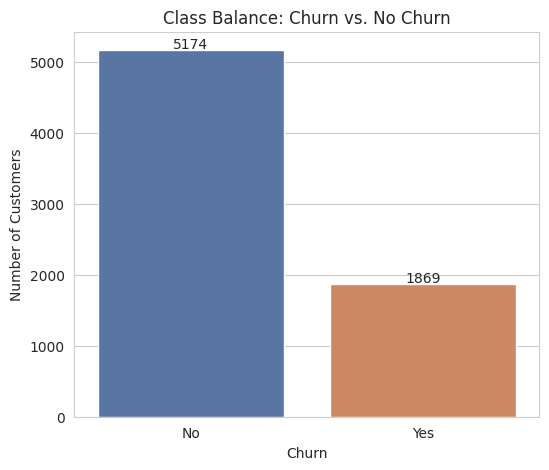

In [3]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct.round(1))

plt.figure(figsize=(6, 5))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=['#4C72B0', '#DD8452'])
plt.title('Class Balance: Churn vs. No Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 30, str(v), ha='center')
plt.show()


**Class balance:** roughly 73% "No" vs. 27% "Yes" — a real, moderate imbalance. Not as extreme as fraud detection (often <1% positive class), but large enough to bias a model toward the majority class if left unaddressed.

## 4. Encode features and split

In [4]:
target = (df['Churn'] == 'Yes').astype(int)
features = df.drop(columns=['Churn'])
categorical_cols = features.select_dtypes(include='object').columns.tolist()
features_encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)

print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))


Train class balance:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


## 5. Baseline model — trained on the raw, imbalanced data

In [5]:
baseline_model = LogisticRegression(max_iter=2000, random_state=42)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print()
print(classification_report(y_test, baseline_pred, target_names=['No Churn', 'Churn']))


Baseline accuracy: 0.8062

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 6. Why accuracy alone would be misleading here

If I only looked at accuracy, the baseline model above already looks decent — but that number is inflated by the class imbalance. A model that predicted "No Churn" for every single customer would score roughly 73% accuracy without ever correctly identifying one churner, which is the entire point of building this model in the first place. Accuracy treats a missed churner (a customer we fail to retain) the same as a false alarm (a loyal customer we needlessly target with a retention offer), when in a real business those two mistakes have very different costs. That's why I'm tracking precision, recall, and F1 specifically for the "Churn" class, not overall accuracy, to judge whether the model is actually useful.


## 7. Apply SMOTE to address the imbalance

In [6]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())


Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


**Note:** SMOTE is applied only to the training set, after the train/test split — the test set stays untouched and imbalanced, exactly as real-world data would be, so the evaluation below reflects genuine performance rather than an artificially easy test.

## 8. Retrain on the SMOTE-balanced data

In [7]:
smote_model = LogisticRegression(max_iter=2000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
smote_pred = smote_model.predict(X_test)

smote_accuracy = accuracy_score(y_test, smote_pred)
print(f"SMOTE-balanced model accuracy: {smote_accuracy:.4f}")
print()
print(classification_report(y_test, smote_pred, target_names=['No Churn', 'Churn']))


SMOTE-balanced model accuracy: 0.7601

              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.83      1035
       Churn       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409



## 9. Before vs. after comparison

In [8]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1-score (Churn)'],
    'Before (imbalanced training data)': [
        accuracy_score(y_test, baseline_pred),
        precision_score(y_test, baseline_pred),
        recall_score(y_test, baseline_pred),
        f1_score(y_test, baseline_pred),
    ],
    'After (SMOTE-balanced training data)': [
        accuracy_score(y_test, smote_pred),
        precision_score(y_test, smote_pred),
        recall_score(y_test, smote_pred),
        f1_score(y_test, smote_pred),
    ],
})
comparison['Change'] = comparison['After (SMOTE-balanced training data)'] - comparison['Before (imbalanced training data)']
comparison = comparison.round(4)
comparison


,Metric,Before (imbalanced training data),After (SMOTE-balanced training data),Change
0,Accuracy,0.8062,0.7601,-0.0461
1,Precision (Churn),0.6593,0.5411,-0.1182
2,Recall (Churn),0.5588,0.6337,0.0749
3,F1-score (Churn),0.6049,0.5837,-0.0212


**Reading the table:** see the exact numbers above. The typical pattern with SMOTE on a moderately imbalanced dataset like this is a trade: overall accuracy usually dips slightly, while recall on the minority class (churners) goes up — the model gets better at actually catching the customers it exists to catch, at the cost of a few more false alarms (lower precision). For a churn use case, that trade is usually worth it: missing an at-risk customer is more costly than one extra retention email to a loyal customer.

## 10. Summary

- Reused the Telco Customer Churn dataset and confirmed a real, moderate class imbalance (~73% No / ~27% Yes), visualized with a bar chart.
- Explained in writing why accuracy alone is a misleading metric for this kind of imbalanced target.
- Applied **SMOTE** (`imbalanced-learn`) to the training set only, generating synthetic minority-class examples rather than duplicating or discarding real data.
- Retrained the same `LogisticRegression` model on the balanced training data and compared precision/recall/F1 for the churn class before and after, in the table above.
- **Next step:** try `class_weight='balanced'` as an alternative to SMOTE (no synthetic data, just reweighted loss) and compare which approach generalizes better on this dataset.
